In [1]:
from ema_forecast_control.utils import path_utils, model_catalogue

SAVE = False

project_name = f'v3_MRT3_every_day_best_latest_all'

labels = ['EMA_mood','EMA_disappointed','EMA_scared','EMA_worry',
    'EMA_down','EMA_sad','EMA_confidence','EMA_stress','EMA_lonely',
    'EMA_energetic','EMA_concentration','EMA_resilience','EMA_tired',
    'EMA_satisfied', 'EMA_relaxed']
input_labels = ['CE', 'CYB', 'CSP', 'BB', 'CC', 'EW', 'JJM', 'PDL']


models = model_catalogue.ModelCatalogue(project_name)
test_data_dir = path_utils.join_base_path('data/AI4U_sample3')

### PLRNN

Calculate cumulative impulse responses for inputs targeted at single nodes

In [2]:
import sys
sys.path.append('..')
import os
import torch as tc
import matplotlib.pyplot as plt

from ema_forecast_control._ai4u_utils.ai4u_utils import determine_model_class
from ema_forecast_control.utils import network_utils
from ema_forecast_control.plrnn.plrnn_model import PLRNN

T = 7

errors_loading_model = 0

plrnn_cir = []

    # results_dir = data_utils.join_ordinal_bptt_path('results', f'v3_MRT{mrt}_every_day')
    # test_data_dir = data_utils.dataset_path(mrt, 'processed_csv_no_con')
    # mrt_cir = []

    # print(f'Collecting models for MRT {mrt}....')
    # models = eval_reallabor_utils.ModelCatalogue(results_dir, only_valid_days=False)
    # networks = []
    # print(f'Perturbation analysis for MRT {mrt}....')
for p, df in path_utils.zip_participants_data(test_data_dir):
    model_dirs = models.get_latest_model_dirs(p, timestep=1000)
    if len(model_dirs) == 0:
        continue
    ensemble_cir = []
    for model_dir in model_dirs:
        args = path_utils.load_args(model_dir)
        if determine_model_class(args) != PLRNN:
            raise ValueError('Model is not PLRNN')
        model = PLRNN()
        model.init_from_model_path(model_dir)
        try:
            Gamma = tc.load(path_utils.join_base_path(model_dir, 'empirical_covariance.pt'))
        except:
            errors_loading_model += 1
            continue
        x = tc.tensor(df[labels].to_numpy()).float()
        network = network_utils.get_network_matrix(model, x, Gamma=Gamma).nanmean(0)
        # model_out_centrality = eval_reallabor_utils.weighted_degree_centrality(network, mode='out', absolute=False)
        # perturb_nodes = tc.arange(len(model_out_centrality))
        C = model.get_parameters()['C']
        B = model.get_parameters()['B']
        
        model_cir = []
        x0 = tc.cat((tc.eye(x.shape[1]).float(), tc.zeros(x.shape[1]).float().unsqueeze(0)), 0)
        for i in range(C.shape[1]):
            perturbation = tc.zeros(C.shape[1]).float()
            perturbation[i] = 1
            subject_cir = network_utils.impulse_response(model, perturbation, T, cumulative=True, relative=True, x0=x0,
                                                                Gamma=Gamma).mean(axis=0)
            model_cir.append(subject_cir)
        model_cir = tc.stack(model_cir, dim=0)
        ensemble_cir.append(model_cir)
    if len(ensemble_cir) == 0:
        continue
    ensemble_cir = tc.stack(ensemble_cir, dim=0).mean(0)
    plrnn_cir.append(ensemble_cir)

plrnn_cir = tc.stack(plrnn_cir, dim=0)

# dims of mrt_cir: (mrt, subject, perturb_node, feature); dims of mrt_out_centrality: (mrt, subject, perturb_node)

Plot cumulative impulse response of each EMI

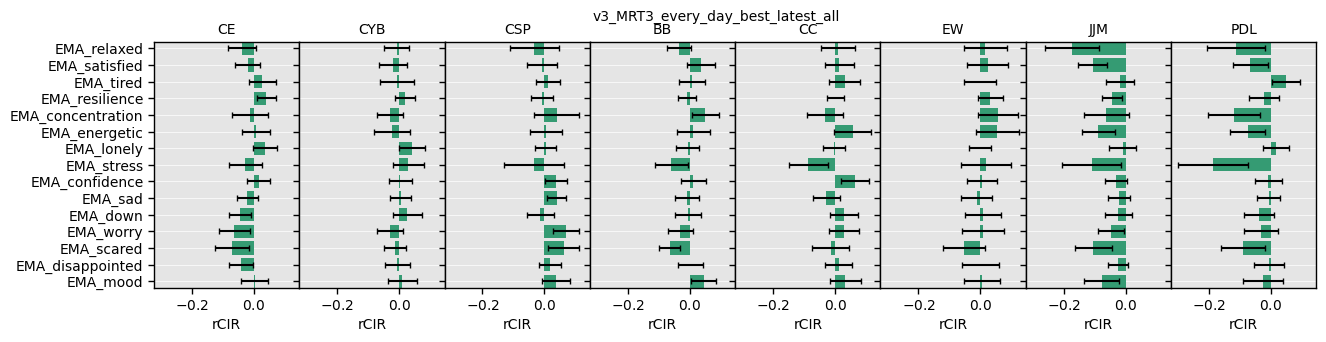

: 

In [ ]:
from scipy import stats

from ema_forecast_control.plotting.plotting_styles import PaperStyle

with PaperStyle():

    fig, axes = plt.subplots(1, 8, figsize=(15, 3.2), sharey=True, sharex=True)
    # valid_map = ~cir[m].mean(2).isnan().any(1)
    z_cir = plrnn_cir

    for i, (emi, ax) in enumerate(zip(range(z_cir.shape[1]), axes.flatten())):

        emi_cir = z_cir[:, emi]            
        ax.barh(tc.arange(z_cir.shape[2]), emi_cir.mean(0), xerr=stats.sem(emi_cir, axis=0), color='#359B73')
        ax.set_yticks(range(z_cir.shape[2]), labels=labels)
        ax.set_title(input_labels[emi])
        ax.set(xlabel='rCIR')
        
    fig.suptitle(project_name)
    # fig.tight_layout()
    plt.subplots_adjust(wspace=0)
    if SAVE:
        fig.savefig(f'../results/_paper/network_perturbation_analyses/plrnn_cir_emi_mrt{mrt}_ensemble.svg')        
    plt.show()
